Clustering

Grouping similar records together.


Project: Customer Segmentation Using K-Means
Business Problem

A shopping mall wants to divide customers into groups so that marketing teams can run personalized campaigns.

For example:

Cluster 1 -> High Income, High Spending

Cluster 2 -> High Income, Low Spending

Cluster 3 -> Low Income, High Spending

Cluster 4 -> Low Income, Low Spending


What We Will Learn

✅ K-Means

✅ Clustering

✅ Elbow Method

✅ Centroids

✅ Cluster Visualization

✅ New Customer Prediction

✅ Business Interpretation

import libraries



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

Cell 2: Generate Dataset

In [2]:
np.random.seed(42)

n = 500

annual_income = np.random.randint(15000, 150000, n)

spending_score = np.random.randint(1, 100, n)

age = np.random.randint(18, 70, n)

df = pd.DataFrame({
    "Age": age,
    "AnnualIncome": annual_income,
    "SpendingScore": spending_score
})

df.head()

,Age,AnnualIncome,SpendingScore
0,42,136958,85
1,50,146932,75
2,64,118694,36
3,57,134879,99
4,60,125268,19


EDA

In [3]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

Shape: (500, 3)

Missing Values:
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64

Statistics:
              Age   AnnualIncome  SpendingScore
count  500.000000     500.000000     500.000000
mean    44.520000   84451.150000      48.458000
std     14.928876   40807.002592      29.220196
min     18.000000   15769.000000       1.000000
25%     32.750000   46960.500000      23.000000
50%     45.000000   85314.500000      49.000000
75%     57.000000  121363.500000      74.000000
max     69.000000  149633.000000      99.000000


Cell 4: Visualize Data

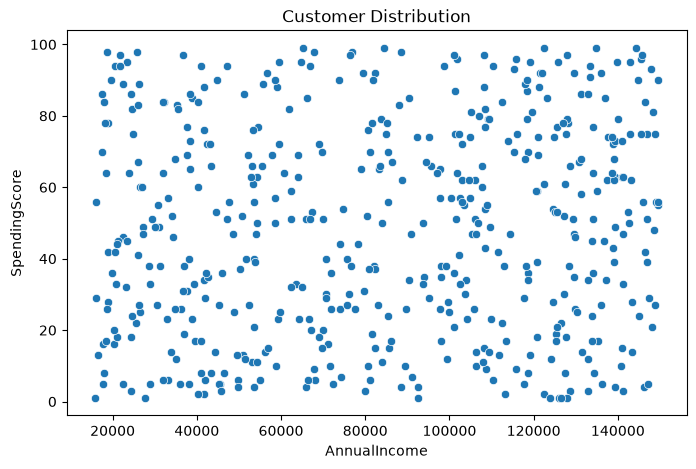

In [4]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore"
)

plt.title("Customer Distribution")

plt.show()

Cell 5: Feature Selection

For customer segmentation we typically use:

In [5]:
X = df[[
    "AnnualIncome",
    "SpendingScore"
]]

print(X)

     AnnualIncome  SpendingScore
0          136958             85
1          146932             75
2          118694             36
3          134879             99
4          125268             19
..            ...            ...
495         51395             12
496        144695             90
497         49620             13
498        143148             62
499         35559             82

[500 rows x 2 columns]


Cell 6: Scaling

Very Important.

K-Means uses distance.

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Cell 7: Elbow Method

Most Important K-Means Step.

What is WCSS? Within Cluster Sum of Squares, measures: Distance of points
from cluster centroids. Better clustering

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

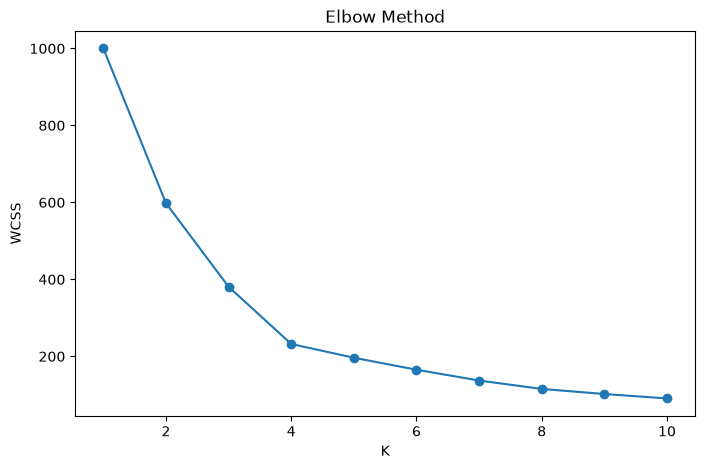

In [7]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

    plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

Cell 8: Train K-Means

Suppose Elbow suggests:

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

Cell 9: View Clusters

In [9]:
print(
    df["Cluster"]
    .value_counts()
)

Cluster
1    141
2    128
3    119
0    112
Name: count, dtype: int64


Cell 10: Visualize Clusters

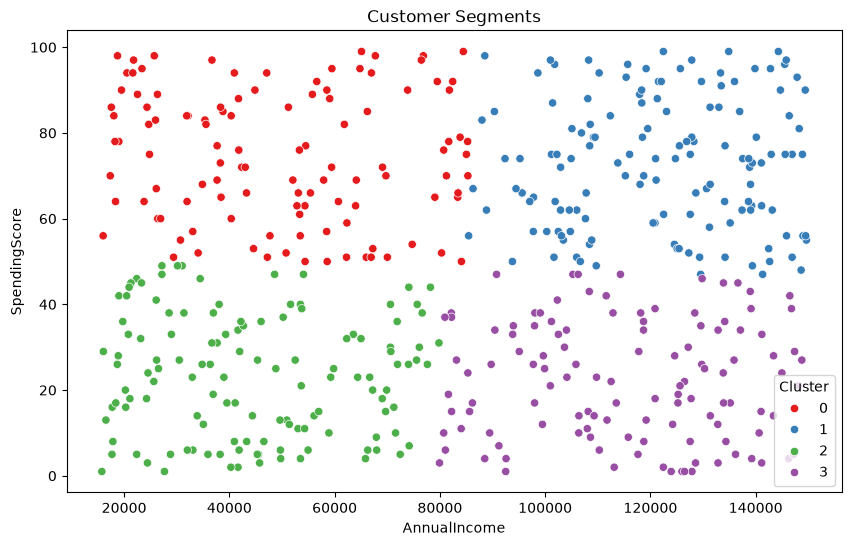

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segments")

plt.show()

Cell 11: Cluster Centers

In [11]:
print(
    kmeans.cluster_centers_
)
#These are scaled values.Convert back to original scale:

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers = pd.DataFrame(
    centers,
    columns=X.columns
)

print(centers)

[[-0.84742016  0.89549   ]
 [ 0.92074245  0.82859176]
 [-0.97672392 -0.86382261]
 [ 0.75720197 -0.89543718]]
    AnnualIncome  SpendingScore
0   49905.071429      74.598214
1  121986.297872      72.645390
2   44633.851563      23.242187
3  115319.378151      22.319328


Cell 12: Cluster Analysis

In [12]:
cluster_summary = (
    df.groupby("Cluster")
      .mean()
)

print(cluster_summary)

               Age   AnnualIncome  SpendingScore
Cluster                                         
0        44.383929   49905.071429      74.598214
1        48.184397  121986.297872      72.645390
2        42.578125   44633.851562      23.242188
3        42.394958  115319.378151      22.319328


Cell 13: Predict New Customer Cluster

In [13]:
new_customer = pd.DataFrame({
    "AnnualIncome":[120000],
    "SpendingScore":[90]
})

new_scaled = scaler.transform(
    new_customer
)

cluster = kmeans.predict(
    new_scaled
)

print("Cluster:", cluster[0])

Cluster: 1
